In [1]:
from langchain_community.document_loaders import TextLoader
loader = TextLoader("speech.txt", encoding = "utf-8")
text_documents= loader.load()
print(text_documents)

[Document(metadata={'source': 'speech.txt'}, page_content="My friends,\n\nWe live in an age of speed. We want success quickly, answers instantly, and recognition overnight. But history has never been shaped by those who moved the fastest. It has always been shaped by those who refused to stop.\n\nPersistence is not loud. It does not announce itself. It does not trend on social media. It wakes up quietly every morning and says, “Try again.”\n\nEvery great breakthrough was once a failure repeated with determination. Every scientist who changed the world first faced rejection. Every entrepreneur who built an empire once faced doubt. Every leader who inspired millions once stood alone.\n\nThe difference between those who succeed and those who surrender is rarely talent. It is rarely intelligence. It is almost always endurance.\n\nThere will be days when progress feels invisible. Days when effort feels wasted. Days when quitting feels reasonable. But understand this: growth is often silent.

In [2]:
import os
from dotenv import load_dotenv


load_dotenv()

True

In [3]:
#web based loader
from langchain_community.document_loaders import WebBaseLoader
import bs4  #beautiful soup for web scrapping

loader = WebBaseLoader(web_path ="https://mayukhportfolio.vercel.app",
                       bs_kwargs= dict(parse_only=bs4.SoupStrainer(
                           class_=("font-sans antialiased dark")
                       )),)  


text = loader.load()
text


USER_AGENT environment variable not set, consider setting it to identify your requests.


[Document(metadata={'source': 'https://mayukhportfolio.vercel.app'}, page_content="MBAboutSkillsProjectsExperienceContactMayukh BanerjeeAI DeveloperI build intelligent systems that think, learn, and scale. Passionate about AI, ML, full-stack development, and agentic systems that solve real-world problems.View ProjectsContact MeGitHubAbout MeI'm a B.Tech Information Technology student at Vellore Institute of Technology (VIT), Vellore, graduating in June 2027. My passion lies in building intelligent, scalable systems that leverage cutting-edge AI and machine learning techniques to solve real-world problems.With hands-on experience in AI agents, NLP, full-stack development, and agentic systems, I've worked on projects ranging from multi-modal voice assistants to explainable AI systems. I thrive in environments where I can push the boundaries of what's possible with technology while maintaining a focus on clean, production-ready code.Beyond coding, I'm deeply interested in event management

In [4]:
from langchain_community.document_loaders import PyPDFLoader
loader = PyPDFLoader("Mayukh Resume.pdf")
doc = loader.load()
doc

[Document(metadata={'producer': 'Microsoft® Word 2021', 'creator': 'Microsoft® Word 2021', 'creationdate': '2026-02-09T22:19:23+05:30', 'author': 'Mayukh Banerjee', 'moddate': '2026-02-09T22:19:23+05:30', 'source': 'Mayukh Resume.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content='Mayukh Banerjee \n9620868983 | mayukhbanerjee011@gmail.com| LinkedIn  | Github \nEDUCATION     \nVellore Institute of Technology                                  Vellore, Tamil Nadu  \nB.Tech in Information Technology    Expected Graduation, June 2027 \no Concentrations: Machine Learning, AI, Full Stack Development \no GPA: 8.43/10 \no Related Coursework: Data Structures & Algorithms, Object Oriented Programming, Database Management Systems, \nSoftware Engineering, Python, Java, Operating Systems, Computer Networks \n \nSKILLS     \nProgramming Languages:  Python, C++, C , JavaScript, Java \nLibraries and Frameworks: scikit-learn, Keras, XGBoost, Hugging Face, TensorFlow, PyTorch, NLTK, NumPy

In [5]:
#transform using text splitter

from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap= 200)
docs = text_splitter.split_documents(doc)

docs


#now you see the pdf is converted into chunks

[Document(metadata={'producer': 'Microsoft® Word 2021', 'creator': 'Microsoft® Word 2021', 'creationdate': '2026-02-09T22:19:23+05:30', 'author': 'Mayukh Banerjee', 'moddate': '2026-02-09T22:19:23+05:30', 'source': 'Mayukh Resume.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}, page_content='Mayukh Banerjee \n9620868983 | mayukhbanerjee011@gmail.com| LinkedIn  | Github \nEDUCATION     \nVellore Institute of Technology                                  Vellore, Tamil Nadu  \nB.Tech in Information Technology    Expected Graduation, June 2027 \no Concentrations: Machine Learning, AI, Full Stack Development \no GPA: 8.43/10 \no Related Coursework: Data Structures & Algorithms, Object Oriented Programming, Database Management Systems, \nSoftware Engineering, Python, Java, Operating Systems, Computer Networks \n \nSKILLS     \nProgramming Languages:  Python, C++, C , JavaScript, Java \nLibraries and Frameworks: scikit-learn, Keras, XGBoost, Hugging Face, TensorFlow, PyTorch, NLTK, NumPy

In [6]:
#Creating and storing embeddings into the DB

from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import Chroma

embeddings = GoogleGenerativeAIEmbeddings(
    model="gemini-embedding-001"
)

db = Chroma.from_documents(
    docs,
    embeddings
)

In [7]:
#vector database
query = "What is his gpa"
result=db.similarity_search(query)
result[0].page_content

'Mayukh Banerjee \n9620868983 | mayukhbanerjee011@gmail.com| LinkedIn  | Github \nEDUCATION     \nVellore Institute of Technology                                  Vellore, Tamil Nadu  \nB.Tech in Information Technology    Expected Graduation, June 2027 \no Concentrations: Machine Learning, AI, Full Stack Development \no GPA: 8.43/10 \no Related Coursework: Data Structures & Algorithms, Object Oriented Programming, Database Management Systems, \nSoftware Engineering, Python, Java, Operating Systems, Computer Networks \n \nSKILLS     \nProgramming Languages:  Python, C++, C , JavaScript, Java \nLibraries and Frameworks: scikit-learn, Keras, XGBoost, Hugging Face, TensorFlow, PyTorch, NLTK, NumPy, Pandas, Seaborn \nTechnologies: Oracle SQL, Git, GitHub, PyCharm, Selenium, FastAPI, REST APIs, Gemini API \nTools: Excel, PowerPoint, Google Apps Script, Google Workspace \n \nPROJECT EXPERIENCE     \nLeBy: Intelligent Legal Assistant (RAG + Machine Learning)     VIT | December 2025'

In [8]:
from langchain_core.prompts import ChatPromptTemplate


prompt = ChatPromptTemplate.from_template("""
Please thing and answer the following questions only based on the context provided.
                                          Think step by step while providing a very helpful answer.
                                          I will pay you more than your expectations if the user finds your answer helpful 

                                          -context:
                                          {context}


                                          -Question: {input}

"""
                                          
                                        

)

Chain Introduction 
Create Stuff Document Chain

In [9]:
from langchain_google_genai import GoogleGenerativeAI

llm = GoogleGenerativeAI(
    model = "gemini-2.5-flash",
    temperature = 1.0
)

In [10]:
from langchain_classic.chains.combine_documents import create_stuff_documents_chain

document_chain = create_stuff_documents_chain(llm,prompt)

Retrievers are like an interface that returns documents given an unstructures query. It is more general than a vector store.
A Retriever does to need to be able to stroe documents, only to return them. Vector stores can be used as a backbone of a retreiver. 

In [11]:
retriever = db.as_retriever()
retriever

VectorStoreRetriever(tags=['Chroma', 'GoogleGenerativeAIEmbeddings'], vectorstore=<langchain_community.vectorstores.chroma.Chroma object at 0x0000028AAAEF6D10>, search_kwargs={})

Retrieval Chain: This chain takes in a user inquiry, which is then passed to a retriever to fetch relevant documents. Thos documents are then passed to an LLM to generate a response

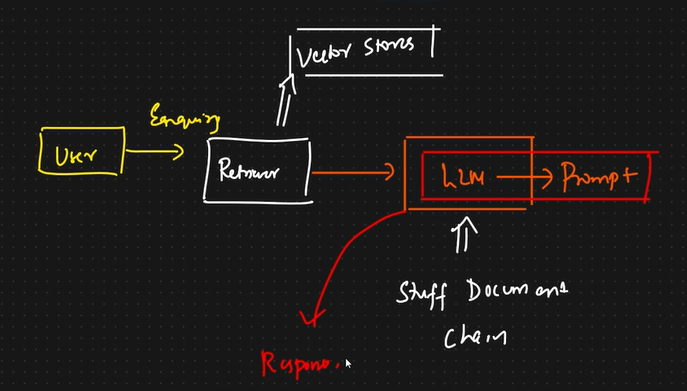


In [12]:
#Creating Retreiver Chain
from langchain_classic.chains import create_retrieval_chain


r_chain = create_retrieval_chain(retriever,document_chain)



In [13]:
response = r_chain.invoke({"input":"What is the CGPA of this candidate"})
response["answer"]

"Based on the context provided, the candidate's GPA is **8.43/10**."